<a href="https://colab.research.google.com/github/Jinwara670710314/lab-ai-69/blob/main/labweek3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello colab" )

hello colab


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target


In [ ]:
X[0]

array([5.1, 3.5, 1.4, 0.2])

In [ ]:
y[0]

np.int64(0)

In [ ]:
print("ขนาดข้อมูล", X.shape)
print("สิ่งที่วัด", iris.feature_names)
print("สายพันธุ์", iris.target_names)
print("จำนวนต่อสายพันธุ์", np.bincount(y))
print("ค่าต่ำสุดแต่ละคอลัมน์", X.min(axis=0))
print("ค่าสูงสุดแต่ละคอลัมน์", X.max(axis=0))

ขนาดข้อมูล (150, 4)
สิ่งที่วัด ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
สายพันธุ์ ['setosa' 'versicolor' 'virginica']
จำนวนต่อสายพันธุ์ [50 50 50]
ค่าต่ำสุดแต่ละคอลัมน์ [4.3 2.  1.  0.1]
ค่าสูงสุดแต่ละคอลัมน์ [7.9 4.4 6.9 2.5]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("กองฝึก", len(X_train), "ดอก")
print("กองสอบ", len(X_test), "ดอก")
print("เฉลยในกองฝึก", np.bincount(y_train))
print("เฉลยในกองสอบ", np.bincount(y_test))

กองฝึก 105 ดอก
กองสอบ 45 ดอก
เฉลยในกองฝึก [31 37 37]
เฉลยในกองสอบ [19 13 13]


In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [ ]:
print("คำตอบ 5 ข้อแรกของนักเรียนหลับตาเดา", baseline.predict(X_test[:5]))
print("คะแนนเดามั่ว", baseline.score(X_test, y_test))

คำตอบ 5 ข้อแรกของนักเรียนหลับตาเดา [1 1 1 1 1]
คะแนนเดามั่ว 0.28888888888888886


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("คะแนนต้นไม้", model.score(X_test, y_test))

คะแนนต้นไม้ 1.0


In [ ]:
from sklearn.tree import export_text

print(export_text(model, feature_names=iris.feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |   |--- class: 1
|   |   |   |--- petal 

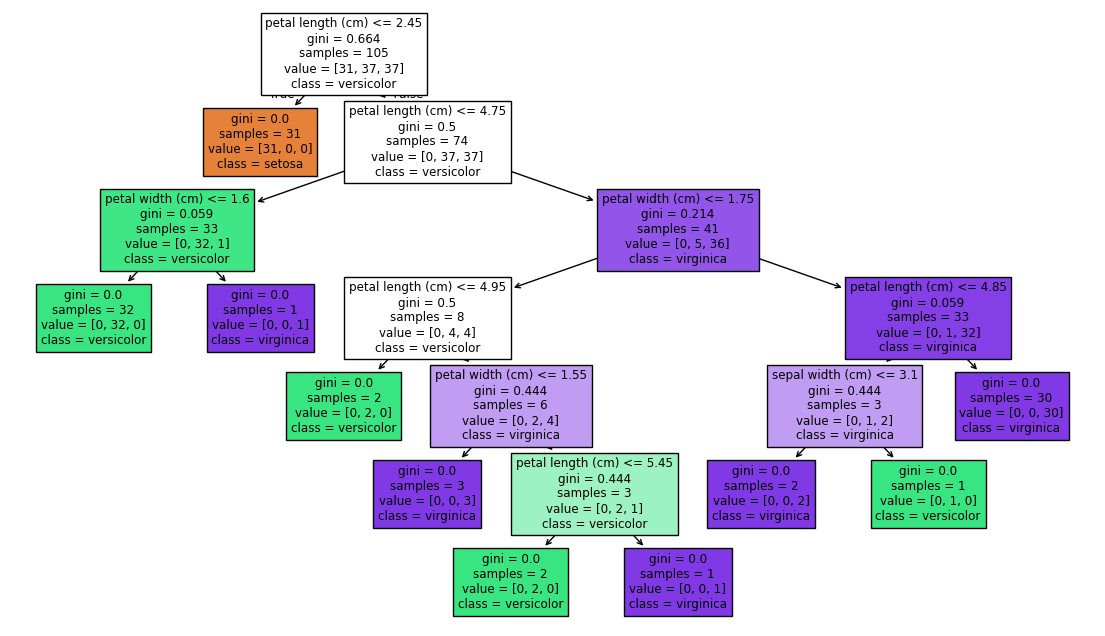

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()

In [ ]:
new_flowers = np.array([
    [5.0, 3.4, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.5, 3.0, 5.8, 2.2],
])

In [ ]:
pred = model.predict(new_flowers)
print("คำตอบ", pred)
print("ชื่อสายพันธุ์", [iris.target_names[p] for p in pred])

คำตอบ [0 1 2]
ชื่อสายพันธุ์ [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [ ]:
print("คะแนนเมื่อสอบด้วยกองฝึก", model.score(X_train, y_train))
print("คะแนนเมื่อสอบด้วยกองสอบ", model.score(X_test, y_test))

คะแนนเมื่อสอบด้วยกองฝึก 1.0
คะแนนเมื่อสอบด้วยกองสอบ 1.0


In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
Xw, yw = wine.data, wine.target
print("ขนาดข้อมูลไวน์", Xw.shape, "แต่ละตระกูล", np.bincount(yw))

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.3, random_state=42)

wine_model = DecisionTreeClassifier(random_state=42)
wine_model.fit(Xw_train, yw_train)

print("คะแนนเมื่อสอบด้วยกองฝึก", round(wine_model.score(Xw_train, yw_train), 4))
print("คะแนนเมื่อสอบด้วยกองสอบ", round(wine_model.score(Xw_test, yw_test), 4))

ขนาดข้อมูลไวน์ (178, 13) แต่ละตระกูล [59 71 48]
คะแนนเมื่อสอบด้วยกองฝึก 1.0
คะแนนเมื่อสอบด้วยกองสอบ 0.963


In [ ]:
X_leak = np.vstack([Xw_train, Xw_test])
y_leak = np.concatenate([yw_train, yw_test])

leak_model = DecisionTreeClassifier(random_state=42)
leak_model.fit(X_leak, y_leak)

print("คะแนนของโมเดลที่เห็นข้อสอบล่วงหน้า", round(leak_model.score(Xw_test, yw_test), 4))

คะแนนของโมเดลที่เห็นข้อสอบล่วงหน้า 1.0


In [ ]:
for rs in [0, 1, 7, 42, 100]:
    a, b, c, d = train_test_split(Xw, yw, test_size=0.3, random_state=rs)
    m = DecisionTreeClassifier(random_state=42).fit(a, c)
    print("random_state", rs, "ได้คะแนน", round(m.score(b, d), 4))

random_state 0 ได้คะแนน 0.9259
random_state 1 ได้คะแนน 0.9074
random_state 7 ได้คะแนน 0.9074
random_state 42 ได้คะแนน 0.963
random_state 100 ได้คะแนน 0.8148


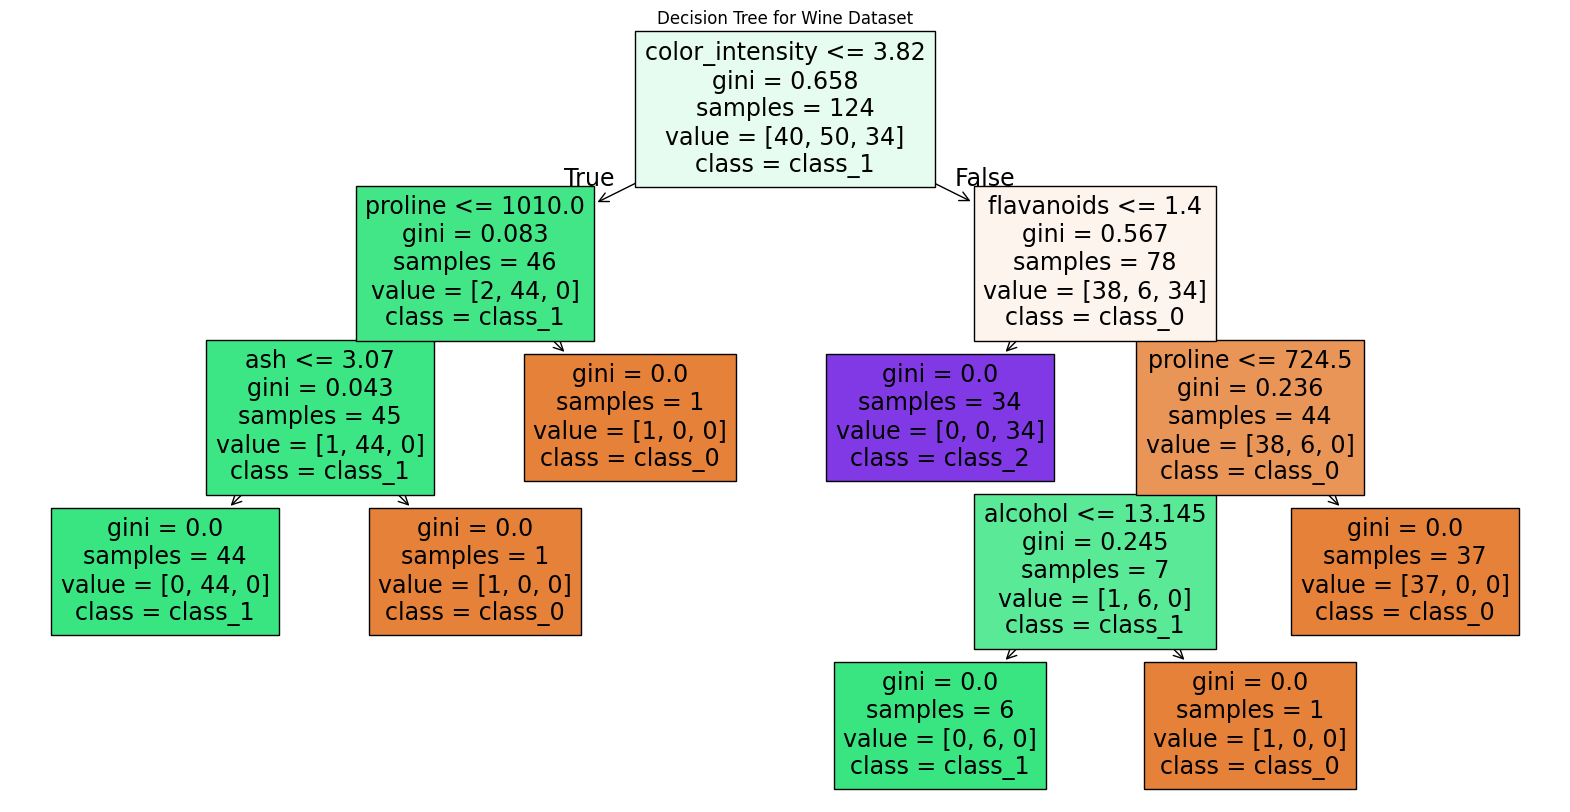

The first question in the decision tree is about: color_intensity


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the decision tree for the wine dataset
plt.figure(figsize=(20, 10))
plot_tree(wine_model, feature_names=wine.feature_names, class_names=wine.target_names.tolist(), filled=True)
plt.title("Decision Tree for Wine Dataset")
plt.show()

# Identify the first feature used for splitting
first_feature_index = wine_model.tree_.feature[0]
first_feature_name = wine.feature_names[first_feature_index]
print(f"The first question in the decision tree is about: {first_feature_name}")

### คำตอบ

1.  **เลข 0.2888 ของนักเรียนหลับตาเดา มาจากการหารเลขอะไรด้วยอะไร**
    *   เลข 0.2888 มาจากการหาร **จำนวนดอกไม้สายพันธุ์ `versicolor` ในกองสอบ** (ซึ่งมี 13 ดอก) ด้วย **จำนวนดอกไม้ทั้งหมดในกองสอบ** (ซึ่งมี 45 ดอก) เพราะโมเดล `DummyClassifier` ถูกตั้งค่าให้เดาสายพันธุ์ที่พบบ่อยที่สุดในกองฝึก (ซึ่งคือ `versicolor` หรือ `virginica` ที่มี 37 ดอกเท่ากัน) และในกองสอบมี `versicolor` 13 ดอก ทำให้ได้คะแนน $13 \div 45 \approx 0.2888$

2.  **กฎข้อแรกที่ต้นไม้ค้นพบเองคืออะไร และแยกสายพันธุ์ไหนออกได้ทันที**
    *   กฎข้อแรกที่ต้นไม้ตัดสินใจ (สำหรับชุดข้อมูล `Iris`) คือ **`petal length (cm) <= 2.45`**
    *   กฎนี้สามารถแยกสายพันธุ์ **`setosa`** ออกไปได้ทันทีทั้งหมด (class: 0)

3.  **บนชุดข้อมูลไวน์ คะแนนกองฝึกกับกองสอบต่างกันเท่าไหร่ และตัวเลขไหนคือความสามารถจริง**
    *   คะแนนกองฝึกคือ 1.0 และคะแนนกองสอบคือ 0.963
    *   คะแนนต่างกันประมาณ **0.037**
    *   ตัวเลขที่บอกถึงความสามารถที่แท้จริงของโมเดลคือ **0.963 (คะแนนกองสอบ)** เพราะเป็นการวัดประสิทธิภาพของโมเดลกับข้อมูลที่ไม่เคยเห็นมาก่อน

4.  **ยกตัวอย่างสถานการณ์จริงมา 1 แบบ ที่ data leakage อาจเกิดโดยไม่ตั้งใจ**
    *   สถานการณ์หนึ่งที่ Data Leakage อาจเกิดขึ้นโดยไม่ตั้งใจคือ **การคำนวณสถิติของฟีเจอร์ (เช่น ค่าเฉลี่ย หรือค่าสูงสุด) จากชุดข้อมูลทั้งหมด (ทั้งส่วนฝึกและส่วนสอบ) ก่อนที่จะทำการแบ่งข้อมูล** ตัวอย่างเช่น หากเราต้องการเติมข้อมูลที่หายไป (impute missing values) ด้วยค่าเฉลี่ย หากเราคำนวณค่าเฉลี่ยของคอลัมน์นั้นจากข้อมูลทั้งหมด แล้วนำไปเติมในทั้งกองฝึกและกองสอบ ข้อมูลจากกองสอบจะรั่วไหลเข้าไปในกองฝึก ทำให้โมเดลเรียนรู้จากข้อมูลที่มันไม่ควรจะรู้ในสถานการณ์จริง